In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

# **Intro Data**

In [ ]:
train_df = pd.read_csv('train.csv')
#test_df = pd.read_csv('test.csv')
#tempdf = pd.read_csv('gender_submission.csv') #Might come useful later

In [ ]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#test_df.head()

In [ ]:
train_df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [ ]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
train_df = train_df.drop('Cabin', axis = 1)
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [ ]:
train_df['Age'].fillna(train_df['Age'].mean(), inplace = True)
train_df['Age']

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

In [ ]:
train_df = train_df.dropna(subset = ['Embarked'])
train_df.shape

(889, 11)

In [ ]:
train_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [ ]:
train_df['Travelling Alone'] = train_df.apply(lambda row: row.SibSp == 0 & row.Parch == 0, axis = 1)

train_df.loc[train_df['Travelling Alone'] == True, 'Travelling Alone'] = 1

train_df.loc[train_df['Travelling Alone'] == False, 'Travelling Alone'] = 0
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Travelling Alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


In [ ]:
train_df = train_df.drop(['Ticket', 'Name'], axis = 1)
train_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Travelling Alone
0,1,0,3,male,22.0,1,0,7.2500,S,0
1,2,1,1,female,38.0,1,0,71.2833,C,0
2,3,1,3,female,26.0,0,0,7.9250,S,1
3,4,1,1,female,35.0,1,0,53.1000,S,0
4,5,0,3,male,35.0,0,0,8.0500,S,1


In [ ]:
train_df.loc[train_df['Sex'] == 'male', 'Sex'] = 1
train_df.loc[train_df['Sex'] == 'female', 'Sex'] = 0
train_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Travelling Alone
0,1,0,3,1,22.0,1,0,7.2500,S,0
1,2,1,1,0,38.0,1,0,71.2833,C,0
2,3,1,3,0,26.0,0,0,7.9250,S,1
3,4,1,1,0,35.0,1,0,53.1000,S,0
4,5,0,3,1,35.0,0,0,8.0500,S,1


In [ ]:
train_df.loc[train_df['Embarked'] == 'Q', 'Embarked'] = 1

train_df.loc[train_df['Embarked'] == 'S', 'Embarked'] = 2

train_df.loc[train_df['Embarked'] == 'C', 'Embarked'] = 3
train_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Travelling Alone
0,1,0,3,1,22.0,1,0,7.2500,2,0
1,2,1,1,0,38.0,1,0,71.2833,3,0
2,3,1,3,0,26.0,0,0,7.9250,2,1
3,4,1,1,0,35.0,1,0,53.1000,2,0
4,5,0,3,1,35.0,0,0,8.0500,2,1


In [ ]:
train_df['Family Size'] = train_df.apply(lambda row: row.SibSp + row.Parch, axis = 1)
train_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Travelling Alone,Family Size
0,1,0,3,1,22.0,1,0,7.2500,2,0,1
1,2,1,1,0,38.0,1,0,71.2833,3,0,1
2,3,1,3,0,26.0,0,0,7.9250,2,1,0
3,4,1,1,0,35.0,1,0,53.1000,2,0,1
4,5,0,3,1,35.0,0,0,8.0500,2,1,0


In [ ]:
''''
test_df = test_df.drop(['Ticket', 'Name', 'Cabin'], axis = 1)

test_df['Age'].fillna(test_df['Age'].mean(), inplace = True)
test_df = test_df.dropna(subset = ['Embarked'])

test_df['Travelling Alone'] = test_df.apply(lambda row: row.SibSp == 0 & row.Parch == 0,axis = 1)

test_df.loc[test_df['Travelling Alone'] == True, 'Travelling Alone'] = 1

test_df.loc[test_df['Travelling Alone'] == False, 'Travelling Alone'] = 0

test_df.loc[test_df['Sex'] == 'male', 'Sex'] = 1

test_df.loc[test_df['Sex'] == 'female', 'Sex'] = 0

test_df['Family Size'] = test_df.apply(lambda row: row.SibSp + row.Parch, axis = 1)
test_df.loc[test_df['Embarked'] == 'Q', 'Embarked'] = 1

test_df.loc[test_df['Embarked'] == 'S', 'Embarked'] = 2

test_df.loc[test_df['Embarked'] == 'C', 'Embarked'] = 3
test_df['Fare'].fillna(test_df['Fare'].mean(), inplace = True)

SyntaxError: ignored

# **LogisticRegression Model**

In [ ]:
train_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Travelling Alone,Family Size
0,1,0,3,1,22.0,1,0,7.2500,2,0,1
1,2,1,1,0,38.0,1,0,71.2833,3,0,1
2,3,1,3,0,26.0,0,0,7.9250,2,1,0
3,4,1,1,0,35.0,1,0,53.1000,2,0,1
4,5,0,3,1,35.0,0,0,8.0500,2,1,0


In [ ]:
#test_df.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Travelling Alone,Family Size
0,892,3,1,34.5,0,0,7.8292,1,1,0
1,893,3,0,47.0,1,0,7.0000,2,0,1
2,894,2,1,62.0,0,0,9.6875,1,1,0
3,895,3,1,27.0,0,0,8.6625,2,1,0
4,896,3,0,22.0,1,1,12.2875,2,0,2


In [ ]:
features = ['Sex', 'SibSp', 'Parch', 'Travelling Alone', 'Family Size', 'Embarked', 'Pclass']

Y = train_df['Survived']
X = train_df[features]

X_test = train_df[features]

In [ ]:
#X_test.isnull().sum()

Sex                 0
SibSp               0
Parch               0
Travelling Alone    0
Family Size         0
Embarked            0
Pclass              0
dtype: int64

In [ ]:
X.isnull().sum()

Sex                 0
SibSp               0
Parch               0
Travelling Alone    0
Family Size         0
Embarked            0
Pclass              0
dtype: int64

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
l = lr.fit(X,Y)
l.score(X,Y)


AttributeError: ignored

In [ ]:
predictions = l.predict(X_test)
predictions

array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,

In [ ]:
pred_df = pd.DataFrame({'Actual Value': train_df['Survived'], 'Predicted Value': predictions})
pred_df

,Actual Value,Predicted Value
0,0,0
1,1,1
2,1,1
3,1,1
4,0,0
...,...,...
886,0,0
887,1,1
888,0,1
889,1,0


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(


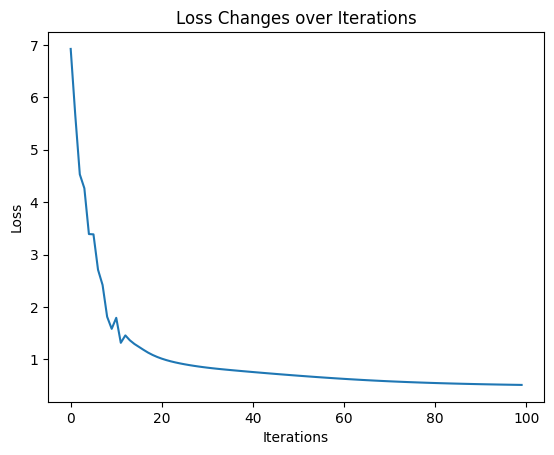

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss  # Mengimpor log_loss
import matplotlib.pyplot as plt
import numpy as np

# Inisialisasi model SGDClassifier (logistic regression)
sgd = SGDClassifier(loss='log', max_iter=100, random_state=42)

# Menyiapkan list untuk menyimpan loss pada setiap iterasi
losses = []

# Pelatihan model dan mengukur loss pada setiap iterasi
for iteration in range(100):  # Anda dapat menyesuaikan jumlah iterasi sesuai kebutuhan
    sgd.partial_fit(X, Y, classes=[0, 1])
    loss = log_loss(Y, sgd.predict_proba(X)[:, 1])
    losses.append(loss)

# Menampilkan grafik perubahan loss
plt.plot(losses)
plt.ylabel('Loss')
plt.xlabel('Iterations')
plt.title('Loss Changes over Iterations')
plt.show()


# **MLPClassifier**